# BloodPressure.

## Exploratory data analysis Section:
    1. Univariate Analysis
    2. Bivariate Analysis
    3. Multi-variate Analysis

### Import the libraries

In [4]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sys.path.append(os.path.join(os.getcwd(), "Utils"))

# find the parent folder of "notebooks"
# add the utils folder to Python path
BASE_DIR = os.path.abspath("..")
sys.path.append(os.path.join(BASE_DIR, "utils"))


# import the RTL module

from Melted import df_melt
from visualization import Plot_R, Plot_L

### Read the dataset

In [5]:
df = pd.read_excel('../Data/BP.xlsx')
df.head()

,day,date,hand,type,morning,noon,night
0,1.0,1405/2/8,R,Systolic,NaN,NaN,NaN
1,NaN,NaN,NaN,Diastolic,NaN,NaN,NaN
2,NaN,NaN,NaN,Pulse,NaN,NaN,NaN
3,NaN,NaN,L,Systolic,149.0,140.0,138.0
4,NaN,NaN,NaN,Diastolic,89.0,74.0,69.0


### Decompose the dataset into Left and Right Arm

first I need to make dimensional of the excel file more understandable to pandas libraries.

In [6]:
df['day'] = df['day'].ffill()
df['hand'] = df['hand'].ffill()
df['date'] = df['date'].ffill()

df.head()

,day,date,hand,type,morning,noon,night
0,1.0,1405/2/8,R,Systolic,NaN,NaN,NaN
1,1.0,1405/2/8,R,Diastolic,NaN,NaN,NaN
2,1.0,1405/2/8,R,Pulse,NaN,NaN,NaN
3,1.0,1405/2/8,L,Systolic,149.0,140.0,138.0
4,1.0,1405/2/8,L,Diastolic,89.0,74.0,69.0


- drop the NaN
- separating the categorical and numerical columns

In [7]:
df = df.dropna()
col_num = ['morning', 'noon', 'night']
col_cat = ['hand', 'type']

- filter the Right Hand

In [8]:
# filtering the right hand
df_R = df[df['hand'] == 'R']
df_R = df_R.drop('hand' , axis=1)
df_R_s = df_R[df_R['type'] == 'Systolic'] 
df_R_d =  df_R[df_R['type'] == 'Diastolic'] 
df_R_p =  df_R[df_R['type'] == 'Pulse']


df_R.head(10)

,day,date,type,morning,noon,night
18,4.0,1405/2/11,Systolic,133.0,137.0,133.0
19,4.0,1405/2/11,Diastolic,60.0,73.0,76.0
20,4.0,1405/2/11,Pulse,56.0,78.0,71.0
24,5.0,1405/2/12,Systolic,130.0,116.0,119.0
25,5.0,1405/2/12,Diastolic,75.0,58.0,68.0
26,5.0,1405/2/12,Pulse,59.0,66.0,64.0
30,6.0,1405/2/13,Systolic,121.0,128.0,121.0
31,6.0,1405/2/13,Diastolic,68.0,72.0,67.0
32,6.0,1405/2/13,Pulse,60.0,83.0,76.0
36,7.0,1405/2/14,Systolic,121.0,121.0,118.0


- filter the Left Hand

In [9]:
# filtering the left hand
df_L = df[df['hand'] == 'L']
df_L = df_L.drop('hand' , axis=1)
df_L_s = df_L[df_L['type'] == 'Systolic'] 
df_L_d =  df_L[df_L['type'] == 'Diastolic'] 
df_L_p =  df_L[df_L['type'] == 'Pulse']

df_L.head()

,day,date,type,morning,noon,night
3,1.0,1405/2/8,Systolic,149.0,140.0,138.0
4,1.0,1405/2/8,Diastolic,89.0,74.0,69.0
5,1.0,1405/2/8,Pulse,65.0,83.0,62.0
9,2.0,1405/2/9,Systolic,151.0,141.0,137.0
10,2.0,1405/2/9,Diastolic,78.0,75.0,75.0


### Making Dataframe usable.

What I mean is to make the dataframe usable, I created a Function that you can find in `Utils`, That make the dataset based on the Arm side. with Measurements in order of time `morning`, `noon` and `night` In one column instead of Three columns, with this result I can do Analysis of the Total BP measurements instead of just in the `morning` or just in the `night` column

In [10]:
# melt the dataset. (On the Left side)
df_L_pt = df_melt(df_L_p)
df_L_st = df_melt(df_L_s)
df_L_dt = df_melt(df_L_d)

    day       date   type time_of_day  measurement
0   3.0  1405/2/10  Pulse     morning         64.0
1   3.0  1405/2/10  Pulse        noon         67.0
2   3.0  1405/2/10  Pulse       night         69.0
3   4.0  1405/2/11  Pulse     morning         54.0
4   4.0  1405/2/11  Pulse        noon         72.0
5   4.0  1405/2/11  Pulse       night         74.0
6   5.0  1405/2/12  Pulse     morning         60.0
7   5.0  1405/2/12  Pulse        noon         65.0
8   5.0  1405/2/12  Pulse       night         68.0
9   6.0  1405/2/13  Pulse     morning         64.0
10  6.0  1405/2/13  Pulse        noon         83.0
11  6.0  1405/2/13  Pulse       night         70.0
12  7.0  1405/2/14  Pulse     morning         60.0
13  7.0  1405/2/14  Pulse        noon         73.0
14  7.0  1405/2/14  Pulse       night         60.0
15  1.0   1405/2/8  Pulse     morning         65.0
16  1.0   1405/2/8  Pulse        noon         83.0
17  1.0   1405/2/8  Pulse       night         62.0
18  2.0   1405/2/9  Pulse     m

In [11]:
# melt the dataset. (On the Left side)
df_R_pt = df_melt(df_R_p)
df_R_st = df_melt(df_R_s)
df_R_dt = df_melt(df_R_d)

    day       date   type time_of_day  measurement
0   4.0  1405/2/11  Pulse     morning         56.0
1   4.0  1405/2/11  Pulse        noon         78.0
2   4.0  1405/2/11  Pulse       night         71.0
3   5.0  1405/2/12  Pulse     morning         59.0
4   5.0  1405/2/12  Pulse        noon         66.0
5   5.0  1405/2/12  Pulse       night         64.0
6   6.0  1405/2/13  Pulse     morning         60.0
7   6.0  1405/2/13  Pulse        noon         83.0
8   6.0  1405/2/13  Pulse       night         76.0
9   7.0  1405/2/14  Pulse     morning         60.0
10  7.0  1405/2/14  Pulse        noon         70.0
11  7.0  1405/2/14  Pulse       night         70.0
    day       date      type time_of_day  measurement
0   4.0  1405/2/11  Systolic     morning        133.0
1   4.0  1405/2/11  Systolic        noon        137.0
2   4.0  1405/2/11  Systolic       night        133.0
3   5.0  1405/2/12  Systolic     morning        130.0
4   5.0  1405/2/12  Systolic        noon        116.0
5   5.0  1405

## 1. Univariate Analysis

In [12]:
melted_list = [df_L_pt , df_L_st , df_L_dt]
name = ['Pulse', 'Systolic', 'Diastolic']

for d, n in zip(melted_list,name):
    print('-'*24 , f'Average value for {n} on the Left Arm', ''*25)
    print(d.groupby('time_of_day', observed=False )['measurement'].mean())
    print('-'*50)

------------------------ Average value for Pulse on the Left Arm 
time_of_day
morning    61.000000
noon       72.428571
night      67.428571
Name: measurement, dtype: float64
--------------------------------------------------
------------------------ Average value for Systolic on the Left Arm 
time_of_day
morning    133.142857
noon       131.857143
night      136.142857
Name: measurement, dtype: float64
--------------------------------------------------
------------------------ Average value for Diastolic on the Left Arm 
time_of_day
morning    77.142857
noon       71.571429
night      74.714286
Name: measurement, dtype: float64
--------------------------------------------------


In [13]:
melted_list = [df_R_pt , df_R_st , df_R_dt]
name = ['Pulse', 'Systolic', 'Diastolic']

for d, n in zip(melted_list,name):
    print('-'*24 , f'Average value for {n} on the Right Arm', ''*25)
    print(d.groupby('time_of_day', observed=False )['measurement'].mean())
    print('-'*50)

------------------------ Average value for Pulse on the Right Arm 
time_of_day
morning    58.75
noon       74.25
night      70.25
Name: measurement, dtype: float64
--------------------------------------------------
------------------------ Average value for Systolic on the Right Arm 
time_of_day
morning    126.25
noon       125.50
night      122.75
Name: measurement, dtype: float64
--------------------------------------------------
------------------------ Average value for Diastolic on the Right Arm 
time_of_day
morning    68.75
noon       67.25
night      71.50
Name: measurement, dtype: float64
--------------------------------------------------


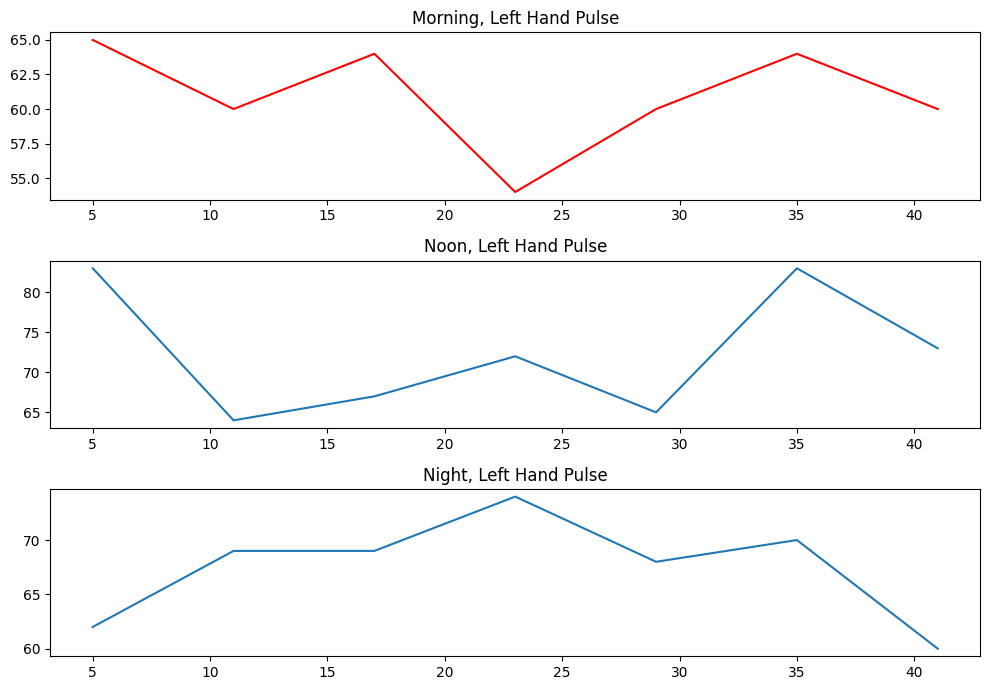

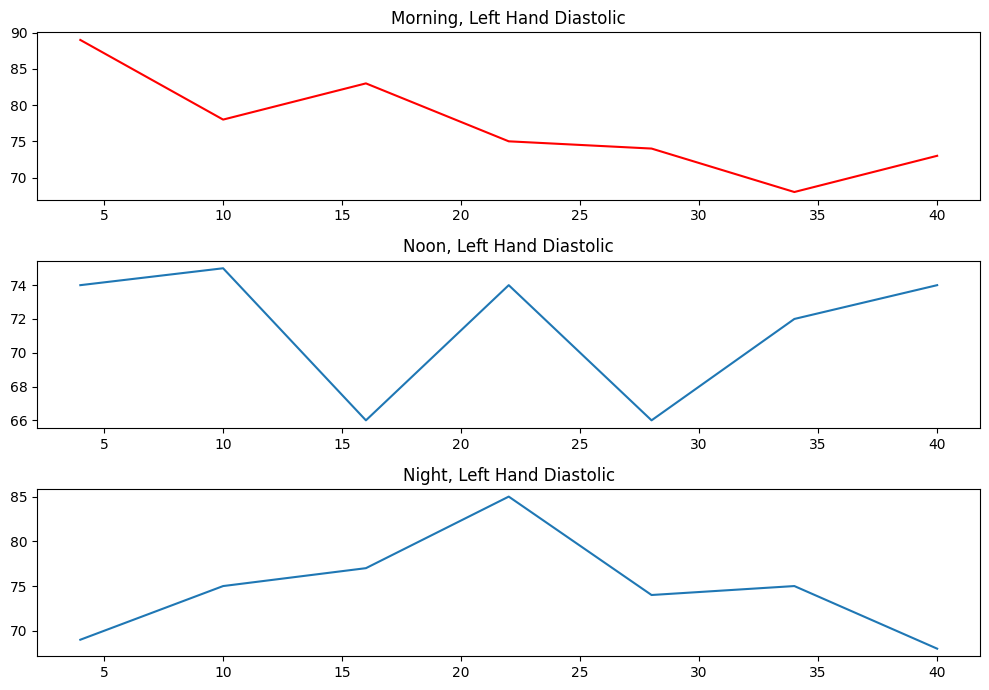

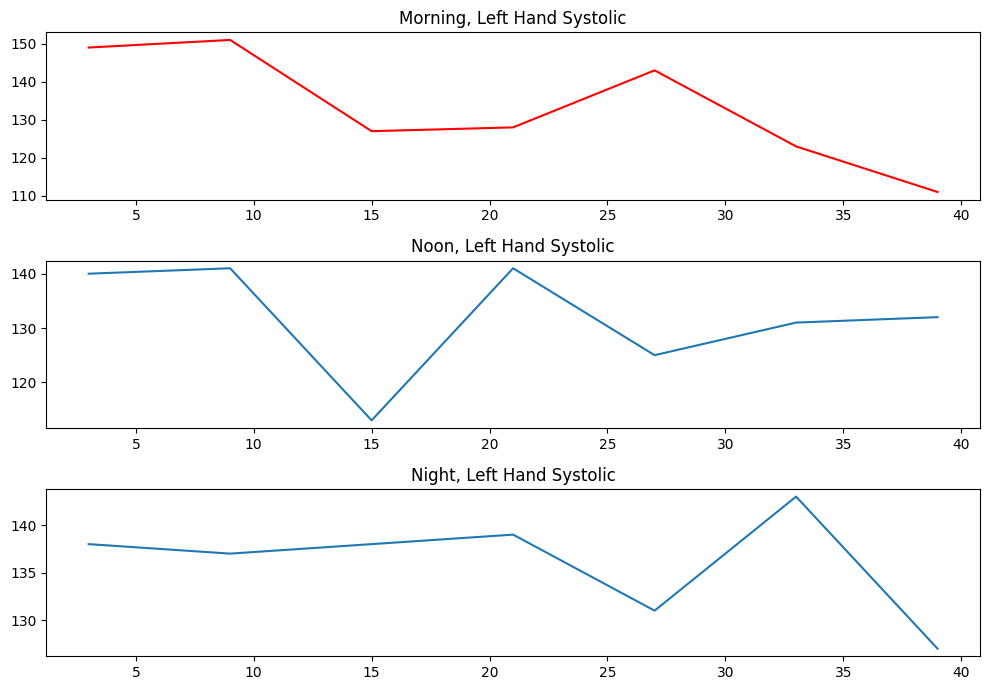

In [14]:
# Analysis of Left hand

datasets = [df_L_p , df_L_d , df_L_s]
names = ['Pulse' , 'Diastolic', 'Systolic']

Plot_L(datasets, names)

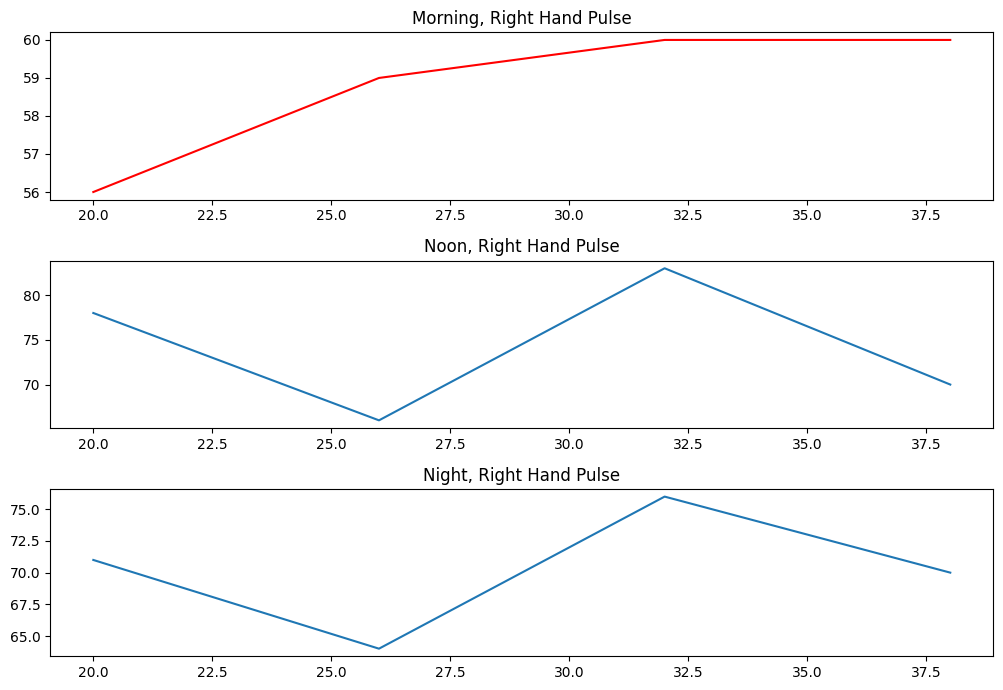

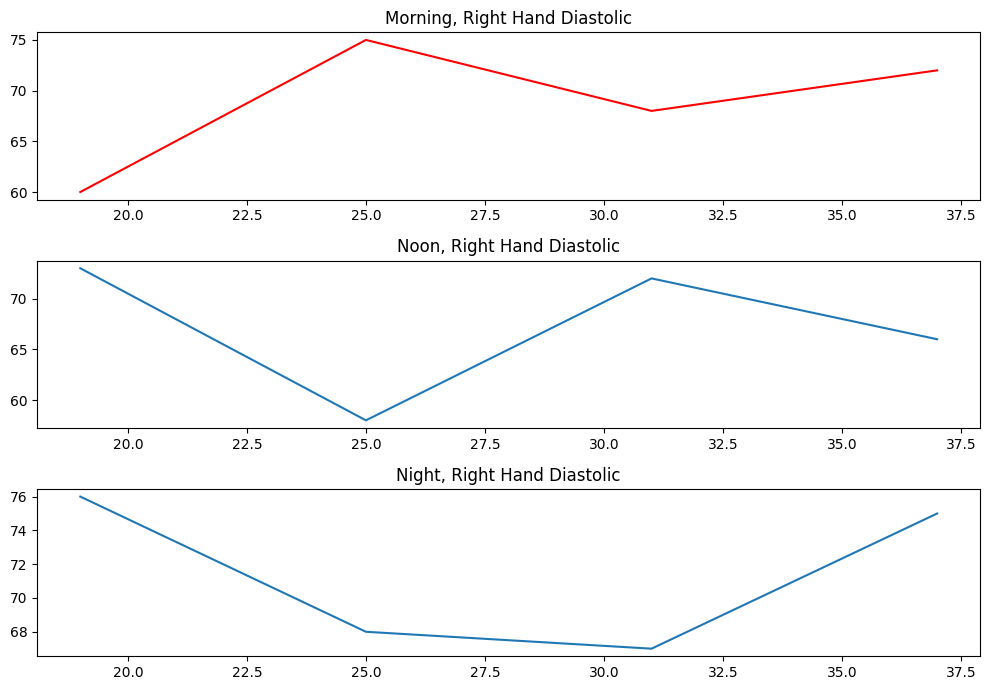

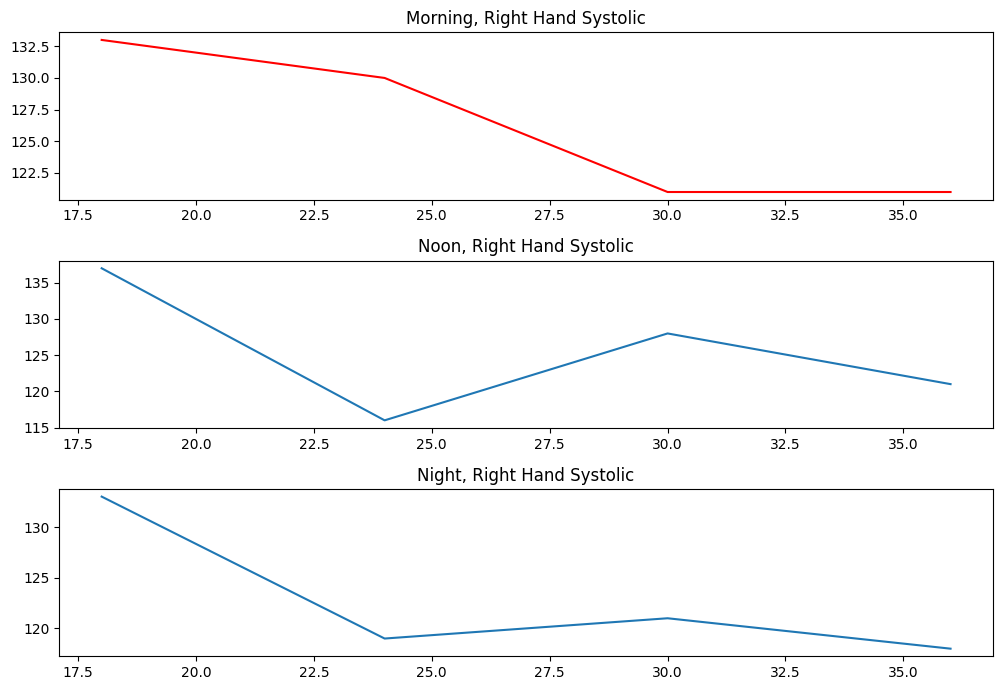

In [16]:
# Analysis of Right hand

datasets = [df_R_p , df_R_d , df_R_s]
names = ['Pulse' , 'Diastolic', 'Systolic']

Plot_R(datasets, names)

# this is were you develope T-Test to comapare if 
# getting BP with Right or Left hand would differ 
# in any case.


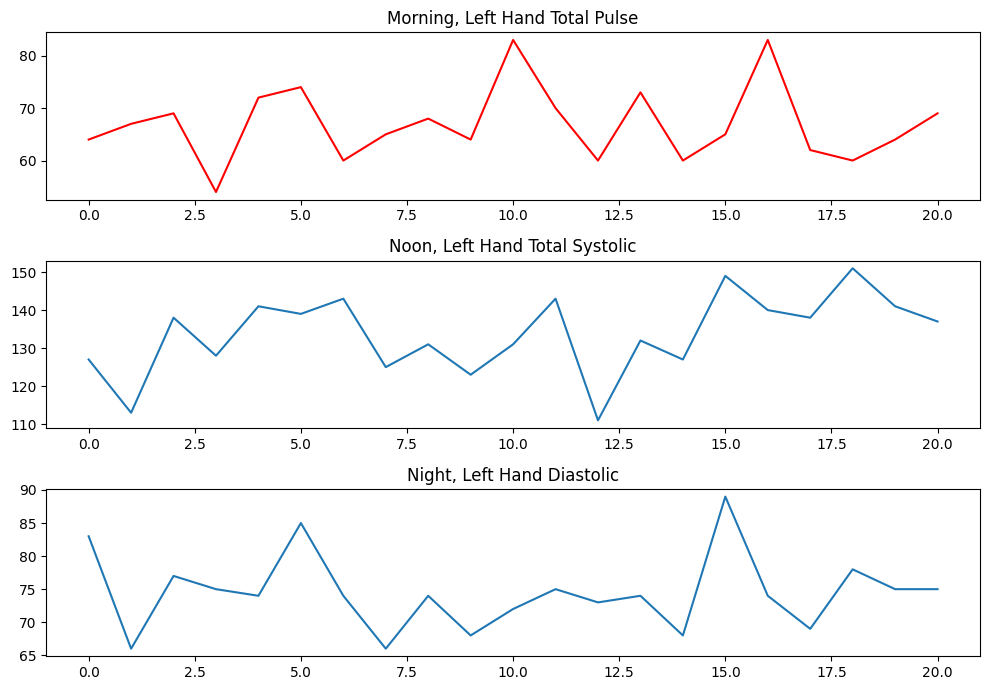

In [21]:
fig, ax = plt.subplots(3,1,figsize=(10,7))

ax[0].plot(df_L_pt['measurement'], color = 'red')
ax[0].set_title('Morning, Left Hand Total Pulse')

ax[1].plot(df_L_st['measurement'])
ax[1].set_title('Noon, Left Hand Total Systolic')

ax[2].plot(df_L_dt['measurement'])
ax[2].set_title('Night, Left Hand Diastolic')
plt.tight_layout()
plt.show()

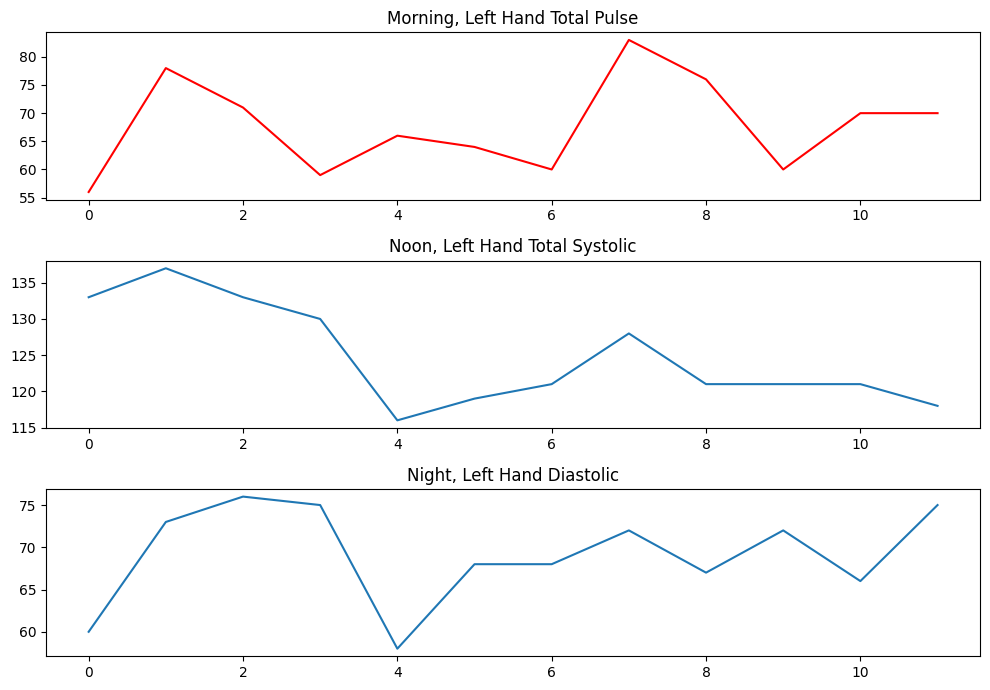

In [22]:
fig, ax = plt.subplots(3,1,figsize=(10,7))

ax[0].plot(df_R_pt['measurement'], color = 'red')
ax[0].set_title('Morning, Left Hand Total Pulse')

ax[1].plot(df_R_st['measurement'])
ax[1].set_title('Noon, Left Hand Total Systolic')

ax[2].plot(df_R_dt['measurement'])
ax[2].set_title('Night, Left Hand Diastolic')
plt.tight_layout()
plt.show()